## Downloading And Pre-processing Dataset

### Downlad dataset
Using kaggle's code to download data from:
- url: https://kaggle.com/alexteboul/diabetes-health-indicators-dataset

at output path : "/datasets"

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset", output_dir="./datasets")

print("Path to dataset files:", path)

c:\Users\tikad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 6.03M/6.03M [00:02<00:00, 3.05MB/s]

Extracting files...


Path to dataset files: ./datasets


### Remove unnecessary directories and files
Only keep `diabetes_binary_5050split_indicators_BRFSS2015.csv` as it will only be used for the model training. It is because it is pre-cleaned with 50-50 split of diabetic and non-diabetic.

In [2]:
import os
import shutil

shutil.rmtree("./datasets/.complete")

os.remove("./datasets/diabetes_012_health_indicators_BRFSS2015.csv")
os.remove("./datasets/diabetes_binary_health_indicators_BRFSS2015.csv")

## Load Dataset and Clean

### Load dataset
Using pandas to load the saved datasets and view first five rows.

In [3]:
# import libraries
import pandas as pd
import numpy as np 
pd.set_option('display.max_columns', None) # Removes turnications

In [4]:
df = pd.read_csv("./datasets/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### Clean by Renaming columns to human understandable form
The datasets contains names which may be difficult to understand such as DiffWalk, PhysHlth, MentHlth, GenHlth, etc. Therefore renaming each in understandable and lower case for mainitaining structures.

In [5]:
# human readable and understandable mapping
column_mapping = {
    'Diabetes_binary': 'diabetes_target',
    'HighBP': 'high_bp',
    'HighChol': 'high_cholesterol',
    'CholCheck': 'cholesterol_check_5yrs',
    'BMI': 'bmi',
    'Smoker': 'is_smoker',
    'Stroke': 'has_had_stroke',
    'HeartDiseaseorAttack': 'heart_disease_or_attack',
    'PhysActivity': 'physical_activity',
    'Fruits': 'eats_fruit_daily',
    'Veggies': 'eats_veggies_daily',
    'HvyAlcoholConsump': 'heavy_alcohol',
    'AnyHealthcare': 'has_healthcare',
    'NoDocbcCost': 'no_doc_due_to_cost',
    'GenHlth': 'general_health_rating',
    'MentHlth': 'poor_mental_health_days',
    'PhysHlth': 'poor_physical_health_days',
    'DiffWalk': 'difficulty_walking',
    'Sex': 'sex',
    'Age': 'age_category',
    'Education': 'education_level',
    'Income': 'income_level'
}

df = df.rename(columns=column_mapping)
df.head()

,diabetes_target,high_bp,high_cholesterol,cholesterol_check_5yrs,bmi,is_smoker,has_had_stroke,heart_disease_or_attack,physical_activity,eats_fruit_daily,eats_veggies_daily,heavy_alcohol,has_healthcare,no_doc_due_to_cost,general_health_rating,poor_mental_health_days,poor_physical_health_days,difficulty_walking,sex,age_category,education_level,income_level
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### Data analysis
Data is pre-cleaned but still needs some verifications before training the model. Doing few simple checks:
- Data Descriptions
- Check Null Values

In [6]:
# describe
df.describe()

,diabetes_target,high_bp,high_cholesterol,cholesterol_check_5yrs,bmi,is_smoker,has_had_stroke,heart_disease_or_attack,physical_activity,eats_fruit_daily,eats_veggies_daily,heavy_alcohol,has_healthcare,no_doc_due_to_cost,general_health_rating,poor_mental_health_days,poor_physical_health_days,difficulty_walking,sex,age_category,education_level,income_level
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,0.788774,0.042721,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,0.408181,0.202228,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
# Check null values
df.isnull().sum()

diabetes_target              0
high_bp                      0
high_cholesterol             0
cholesterol_check_5yrs       0
bmi                          0
is_smoker                    0
has_had_stroke               0
heart_disease_or_attack      0
physical_activity            0
eats_fruit_daily             0
eats_veggies_daily           0
heavy_alcohol                0
has_healthcare               0
no_doc_due_to_cost           0
general_health_rating        0
poor_mental_health_days      0
poor_physical_health_days    0
difficulty_walking           0
sex                          0
age_category                 0
education_level              0
income_level                 0
dtype: int64

### Statement of Feature Engineering
The dataset contains all the required features by default as it was a curated datataset available in kaggle. Therefore no additional feature engineering was done. The only change made was renaming feature names, and shuffeling dataset before train-val-test splits.

## Shuffle | Save | Split of Dataset
The dataset needs shuffeling which is done with seed 41 so it could be re-created everytime. Then it is saved to the datasets folder as final.csv so renaming and shuffling is not required in next load. Finally, the dataset is splitted to train, val and test set for training, and testing.

In [8]:
# set a seed
seed = 41
# shuffle
df = df.sample(frac=1, random_state=41)
# save
df.to_csv("./datasets/final.csv", index=False )

In [9]:
# splitting dataset

# length
n = len(df)
train_n = int(n * 0.65)
val_n = train_n + int(n*0.2)

# final set
train = df[:train_n]
val = df[train_n:val_n]
test = df[val_n:]

## EDA
EDA is visuallized using different chart showing different things:
- Target Distribution Bar-Chart: This barchart shows the distribution of target class of Diabetic and Non-Diabetic in overall dataset
- Co-relation Heatmap: This heatmap shows co-relation of features with eachother
- BMI Density: This figure shows density of BMI by Diabetes Status.

### Import libraries of Plotting
- matplotlib : For plotting the data
- Seaborn : Library on top of Matplot lib (Simplifies plot code)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

### Target Class Distribution

C:\Users\tikad\AppData\Local\Temp\ipykernel_13276\265065540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diabetes_target', palette="Set2")


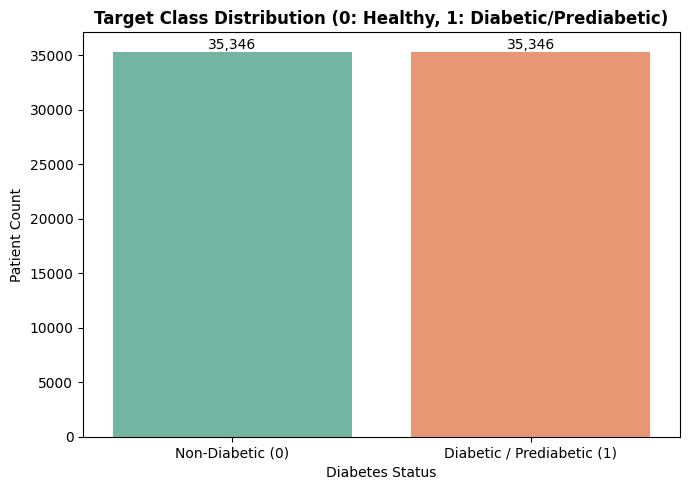

In [11]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='diabetes_target', palette="Set2")
plt.title('Target Class Distribution (0: Healthy, 1: Diabetic/Prediabetic)', fontsize=12, fontweight='bold')
plt.xlabel('Diabetes Status', fontsize=10)
plt.ylabel('Patient Count', fontsize=10)
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic / Prediabetic (1)'])

# annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.savefig("./resources/target_class_distribution.png")
plt.show()
plt.close()

### Co-relation Heatmap

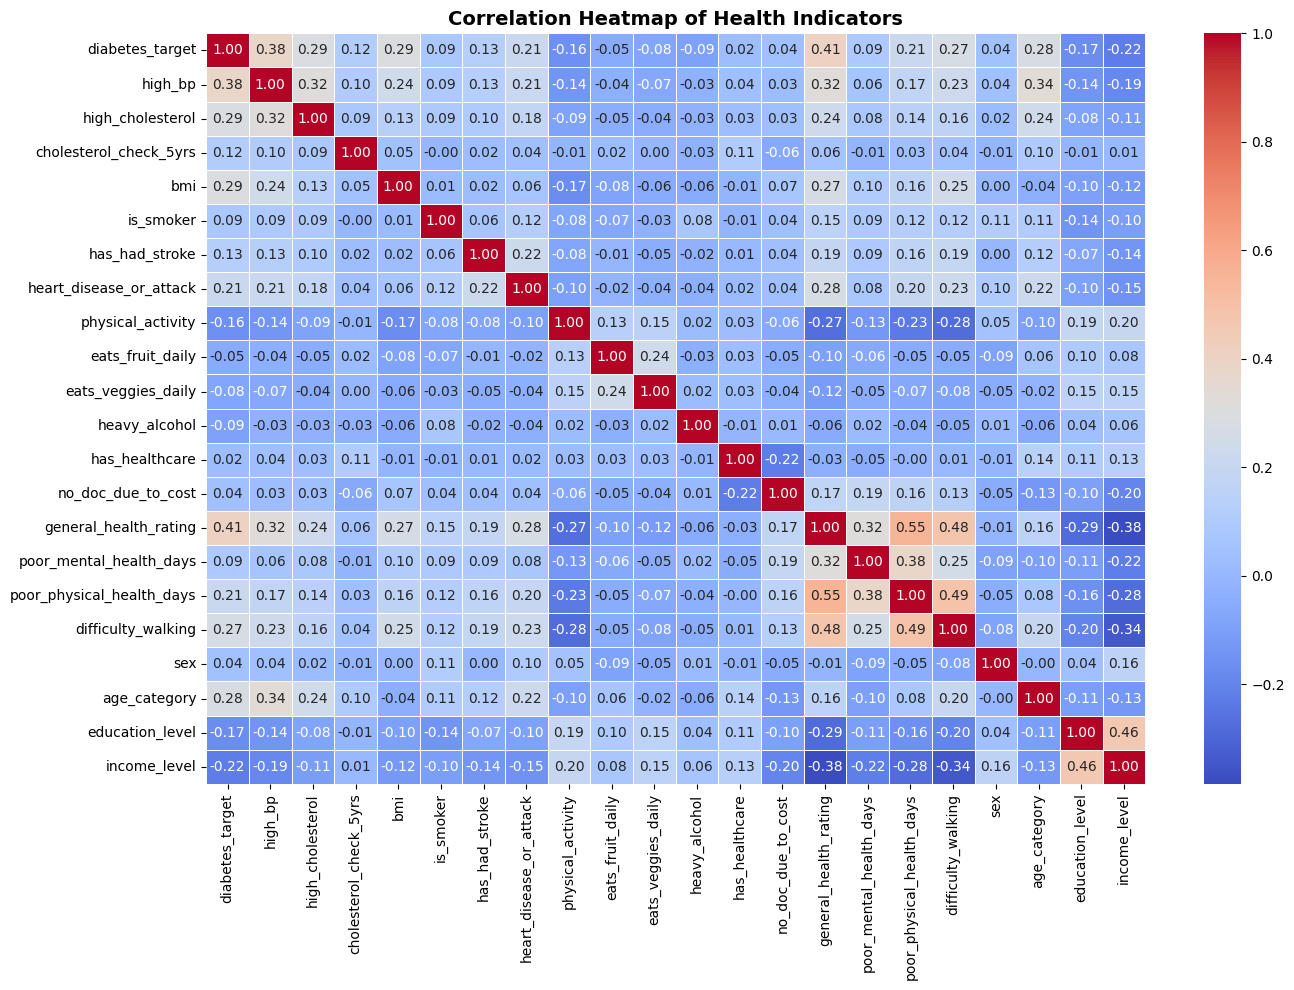

In [12]:
plt.figure(figsize=(14, 10))
# computes correlation matrix of df
corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm', 
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    )
plt.title('Correlation Heatmap of Health Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("./resources/correlation_heatmap_of_health_indicators.png")
plt.show()
plt.close()

### BMI Density plot

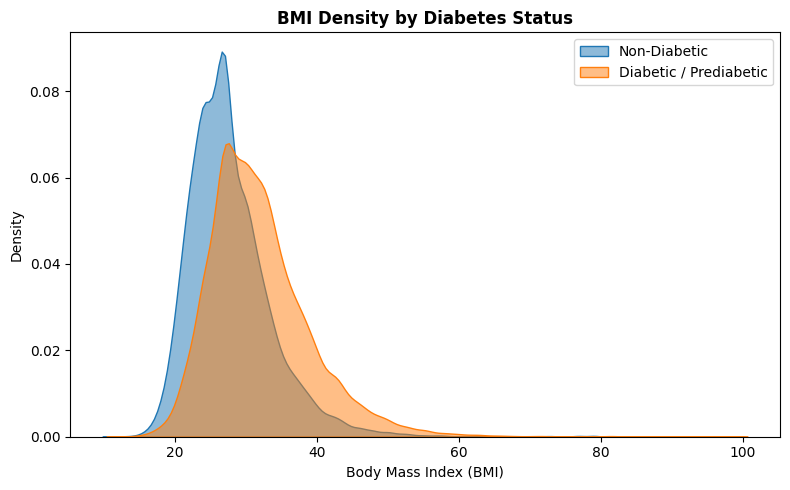

In [13]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df[df["diabetes_target"] == 0],
    x="bmi",
    fill=True,
    alpha=0.5,
    label="Non-Diabetic"
)

sns.kdeplot(
    data=df[df["diabetes_target"] == 1],
    x="bmi",
    fill=True,
    alpha=0.5,
    label="Diabetic / Prediabetic"
)

plt.title("BMI Density by Diabetes Status", fontsize=12, fontweight="bold")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("./resources/bmi_density_plot.png")
plt.show()
plt.close()

## Feature Scaling
The Decision Tree doesnot require feature scaling but Random forest requires it so to maintain control controlled environment, feature scaling is done on continuous variable while creating target and features.

In [14]:
# import Standard Scaler
from sklearn.preprocessing import StandardScaler

# continuous values
# Split data to train, test, val
train_len = int(len(df) * 0.65)
val_len = train_len + int(len(df) * 0.2)

train = df.iloc[:train_len]
val = df.iloc[train_len:val_len]
test = df.iloc[val_len:]

print(f"Train Set shape = {train.shape}")
print(f"Validation Set shape = {val.shape}")
print(f"Test Set shape = {test.shape}")

# continuous value
continuous = [
    "bmi",
    "poor_mental_health_days",
    "poor_physical_health_days",
    "general_health_rating",
    "age_category",
    "education_level",
    "income_level"
]
# scaler 
scaler = {}
# continuous looping
for col in continuous:
    scaler[col] = StandardScaler()
    train[col] = scaler[col].fit_transform(train[[col]]).flatten()
    val[col] = scaler[col].transform(val[[col]]).flatten()
    test[col] = scaler[col].transform(test[[col]]).flatten()
    
# training values
X_train = train.drop(columns=["diabetes_target"])
y_train = train["diabetes_target"]

# validation values
X_val = val.drop(columns=["diabetes_target"])
y_val = val["diabetes_target"]

# test values
X_test = test.drop(columns=["diabetes_target"])
y_test = test["diabetes_target"]

Train Set shape = (45949, 22)
Validation Set shape = (14138, 22)
Test Set shape = (10605, 22)


## Modular Component
The project requires multiple similar steps so modular functions/component is developed to maintain simplicity and modularity. The functions are:
- metrics_calculator: This calcuates the 4 metrics for the recieved inputs and returns a dictonary 
- trianer : This is the function that trains the model in iterations. It takes in `ML model`, dict of model's fixed parameters then calcultes metrics for both train and validation and returns dict with every metrics with and the model.
- line_chart_plotter : This function plots the line chart for all metrics including accuracy, precision, recall and f1-score. It recieves list of objects which is converted to dictonary and for each metrics it is plotted against x_label in parameters.
- tester : This function simply calculates the confusion_matrix, roc/auc and metrics on model recieved in parameters using test set and plots the matrix whilte returning metrics.

### Import basic calculation libraries
The basic modules from scikit-learn helps to develop all the modules easily:
- sklearn.confusion_matrix : calculates confusion matrics
- sklearn.accuracy_score, precision_score, recall_score, f1_score : calculates metrics
- roc_cuve and roc_auc_score : gives roc and auc scores to generate curves

In [15]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_curve, roc_auc_score, confusion_matrix

### metric_calculator module

In [16]:
def metric_calculator(y_true, y_pred, prefix=""):
    return {
        f"{prefix}accuracy":accuracy_score(y_true, y_pred),
        f"{prefix}precision":precision_score(y_true, y_pred),
        f"{prefix}recall":recall_score(y_true, y_pred),
        f"{prefix}f1":f1_score(y_true, y_pred),
    }

### trainer module

In [17]:
import copy

def trainer(model):
    copy_model = copy.deepcopy(model)  # creates a deep copy

    # train the model
    copy_model.fit(X_train, y_train)

    # predictions
    train_pred = copy_model.predict(X_train)
    val_pred = copy_model.predict(X_val)

    train_metrics = metric_calculator(y_train, train_pred, "train_")
    val_metrics = metric_calculator(y_val, val_pred, "val_")

    return {**train_metrics, **val_metrics, "model":copy_model}

### Tester Module

In [18]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

def tester(model, y_true, x):
    # Prediction
    y_pred = model.predict(x)
    # Probability for ROC curve
    y_prob = model.predict_proba(x)[:, 1]
    # metrics
    metrics = metric_calculator(y_true, y_pred)
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    # ROC Curve
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true, y_prob
    )
    # ROC AUC
    roc_auc = roc_auc_score(y_true, y_prob)
    return {
        **metrics,

        "True Positive": tp,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,

        "Confusion Matrix": cm,

        "False Positive Rate": false_positive_rate,
        "True Positive Rate": true_positive_rate,
        "Thresholds": thresholds,

        "ROC AUC Score": roc_auc
    }

### Line Chart Generator

In [19]:
def plot_model_metrics(data, x_col, save_path=None):
    metrics = ["accuracy", "precision", "recall", "f1"]

    plt.figure(figsize=(12, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i + 1)

        plt.title(f"{metric.capitalize()} Score Comparison")

        sns.lineplot(
            data=data,
            x=x_col,
            y=f"train_{metric}",
            label="Train"
        )

        sns.lineplot(
            data=data,
            x=x_col,
            y=f"val_{metric}",
            label="Validation"
        )

        plt.xlabel(x_col.capitalize())
        plt.ylabel(metric.capitalize())
        plt.yticks([tick/100 for tick in range(60, 91, 5)])

        plt.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()
    plt.close()

### Confusion Matrix Plotter

In [20]:
def plot_confusion_matrix(result, class_labels=["Negative", "Positive"], title="Confusion Matrix", save_path=None):
    cm = result["Confusion Matrix"]

    cm_percent = cm / cm.sum() * 100

    labels = [
        [
            f"{cm[i,j]}\n({cm_percent[i,j]:.2f}%)"
            for j in range(cm.shape[1])
        ]
        for i in range(cm.shape[0])
    ]

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

### ROC Curve plot

In [21]:
def plot_roc_curve(result, title="ROC Curve", save_path=None):
    fpr = result["False Positive Rate"]
    tpr = result["True Positive Rate"]
    auc = result["ROC AUC Score"]

    plt.figure(figsize=(7, 5))

    sns.lineplot(
        x=fpr,
        y=tpr,
        label=f"ROC-AUC = {auc:.3f}"
    )

    # Random classifier baseline
    sns.lineplot(
        x=[0, 1],
        y=[0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

## Model Training and Testing
Both models for Decision Tree and Random Forest will be trained and tested. Each graph will be saved.

### Decision Tree for Finding best depth

In [22]:
# import module
from sklearn.tree import DecisionTreeClassifier

In [23]:
# train models
depth_models_dt = [
    {**trainer(DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=seed,
    )), "max_depth":depth} for depth in range(1,16)
]

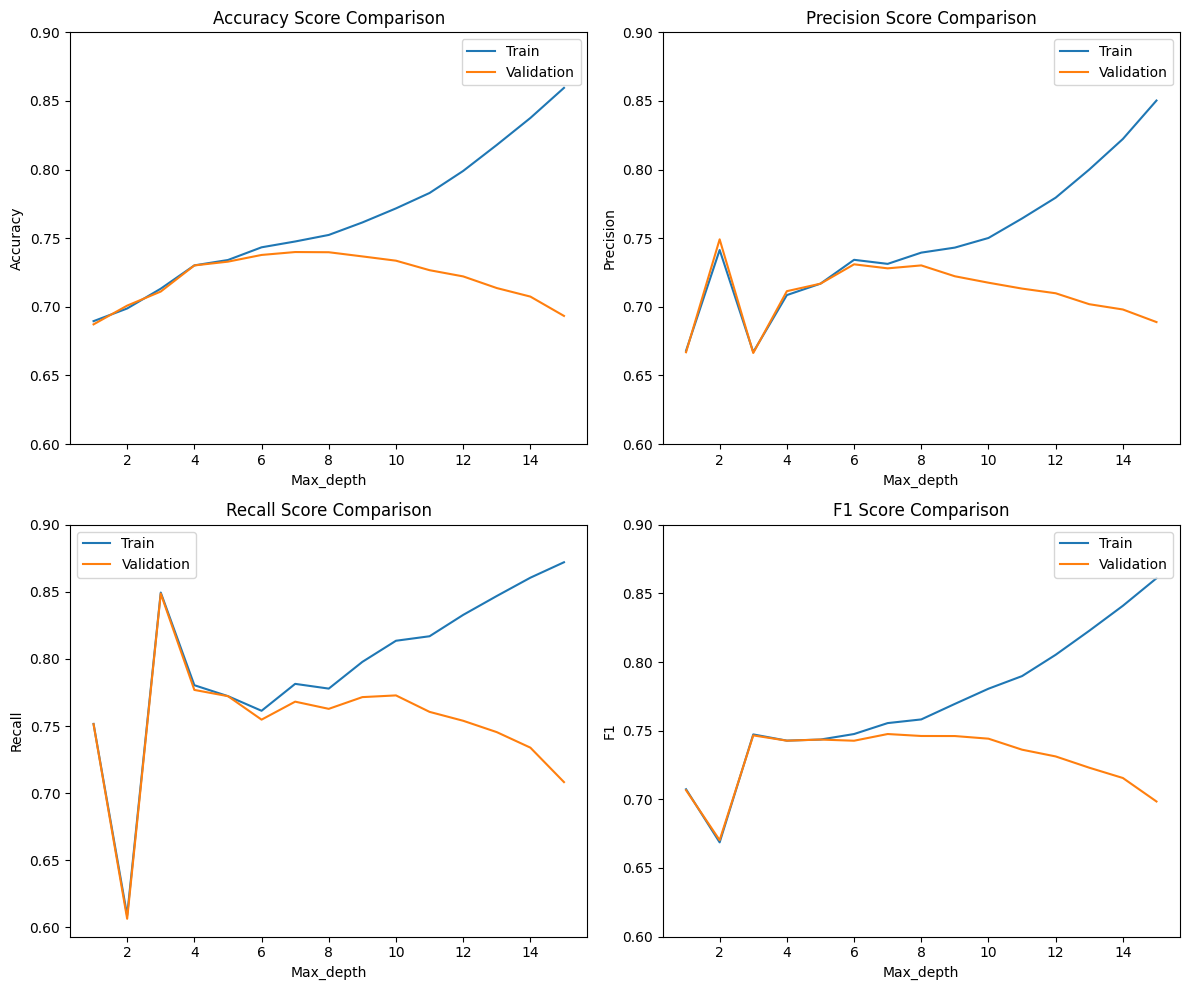

In [24]:
# plot line charts for max_depth
plot_model_metrics(pd.DataFrame(depth_models_dt), x_col="max_depth", save_path="./resources/decision_tree_max_depth_metrics.png")

### Decision Tree for Best Min Samples Leaf

In [25]:
# 8 max depth shows most stable and highest combination
# using max depth 8 for finding min_samples_leaf
min_samples_leaf_model_dt = [
    {**trainer(DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=min_samples_leaf,
        criterion="gini",
        random_state=seed
        
    )), "min_samples_leaf":min_samples_leaf} for min_samples_leaf in range(1,51,5)
]

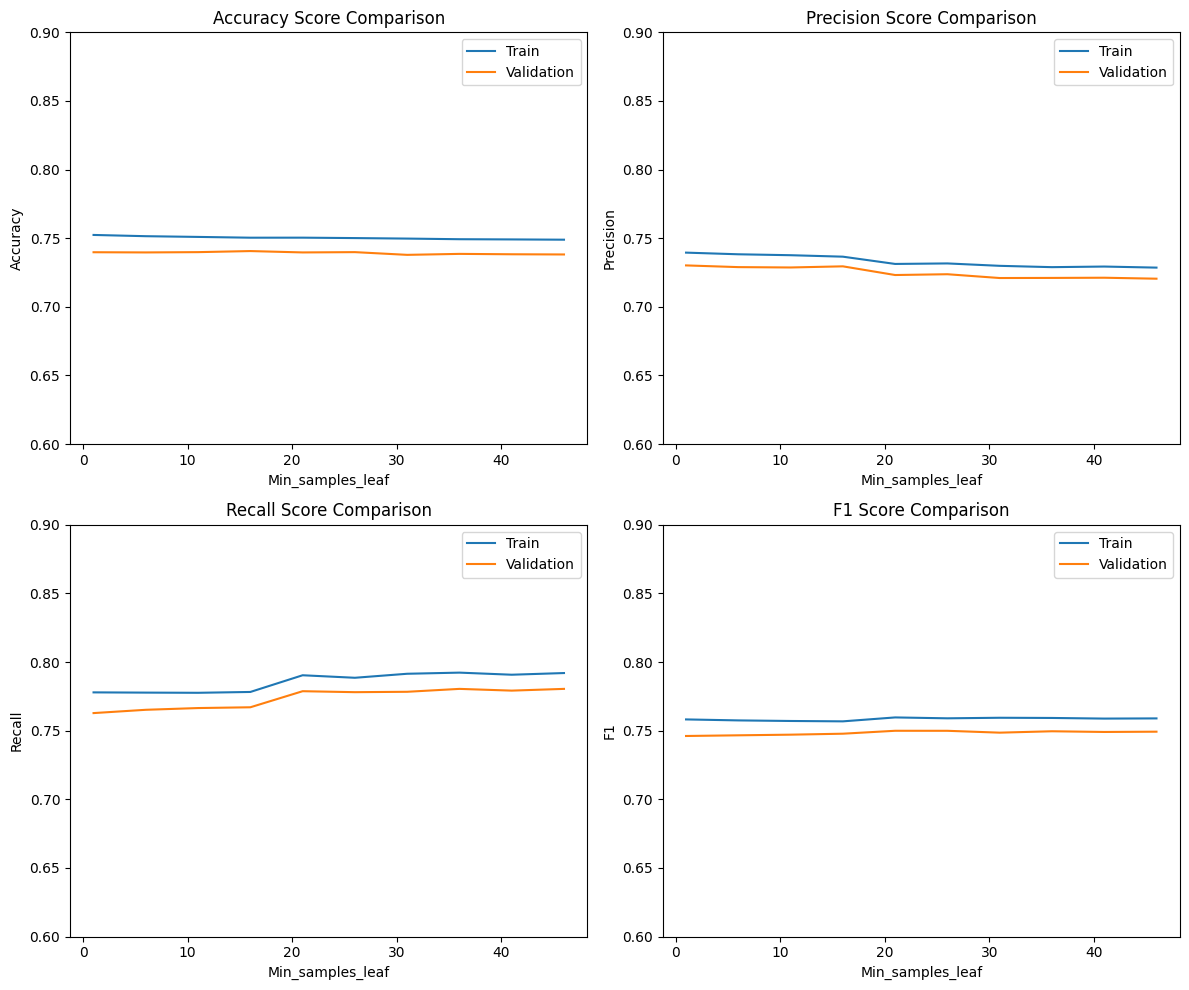

In [26]:
plot_model_metrics(pd.DataFrame(min_samples_leaf_model_dt), x_col="min_samples_leaf", save_path="./resources/decision_tree_max_min_samples_leaf_metrics.png")

### Use Tester Module on Decision Tree

In [27]:
# best models
decision_tree = next(item["model"] for item in min_samples_leaf_model_dt if item["min_samples_leaf"] == 21)

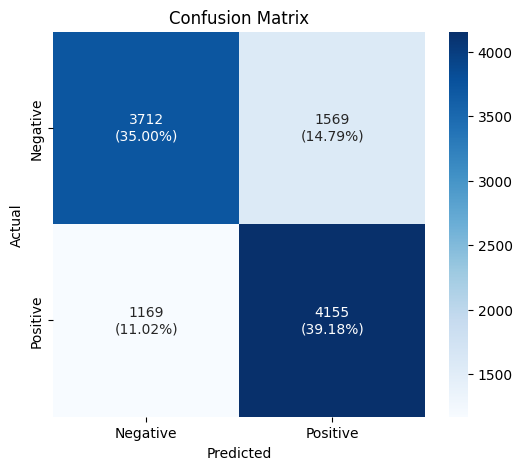

In [28]:
# tester models for decision tree
dt_test = tester(decision_tree, y_test, X_test)

# plot confusion matrix
plot_confusion_matrix(dt_test, save_path="./resources/confusuin_matrix_dt_test")

### Show ROC Curves for Decision Tree's Best Model

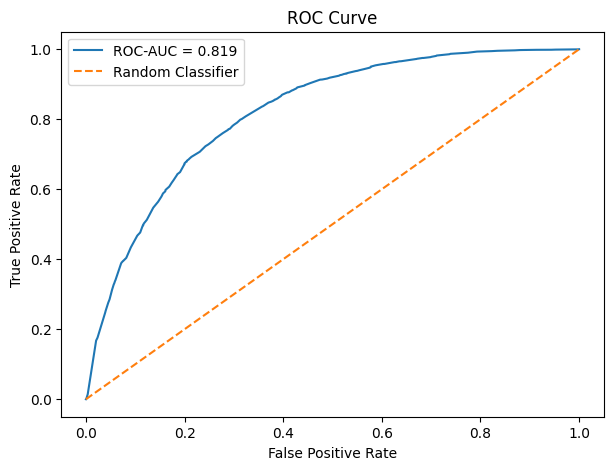

In [29]:
# plot roc auc curve
plot_roc_curve(dt_test, save_path="./resources/roc_dt_test.png")

### Random Forest for Finding best depth

In [30]:
# import module
from sklearn.ensemble import RandomForestClassifier

In [31]:
# train models
depth_models_rf = [
    {**trainer(RandomForestClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=seed,
    )), "max_depth":depth} for depth in range(1,16)
]

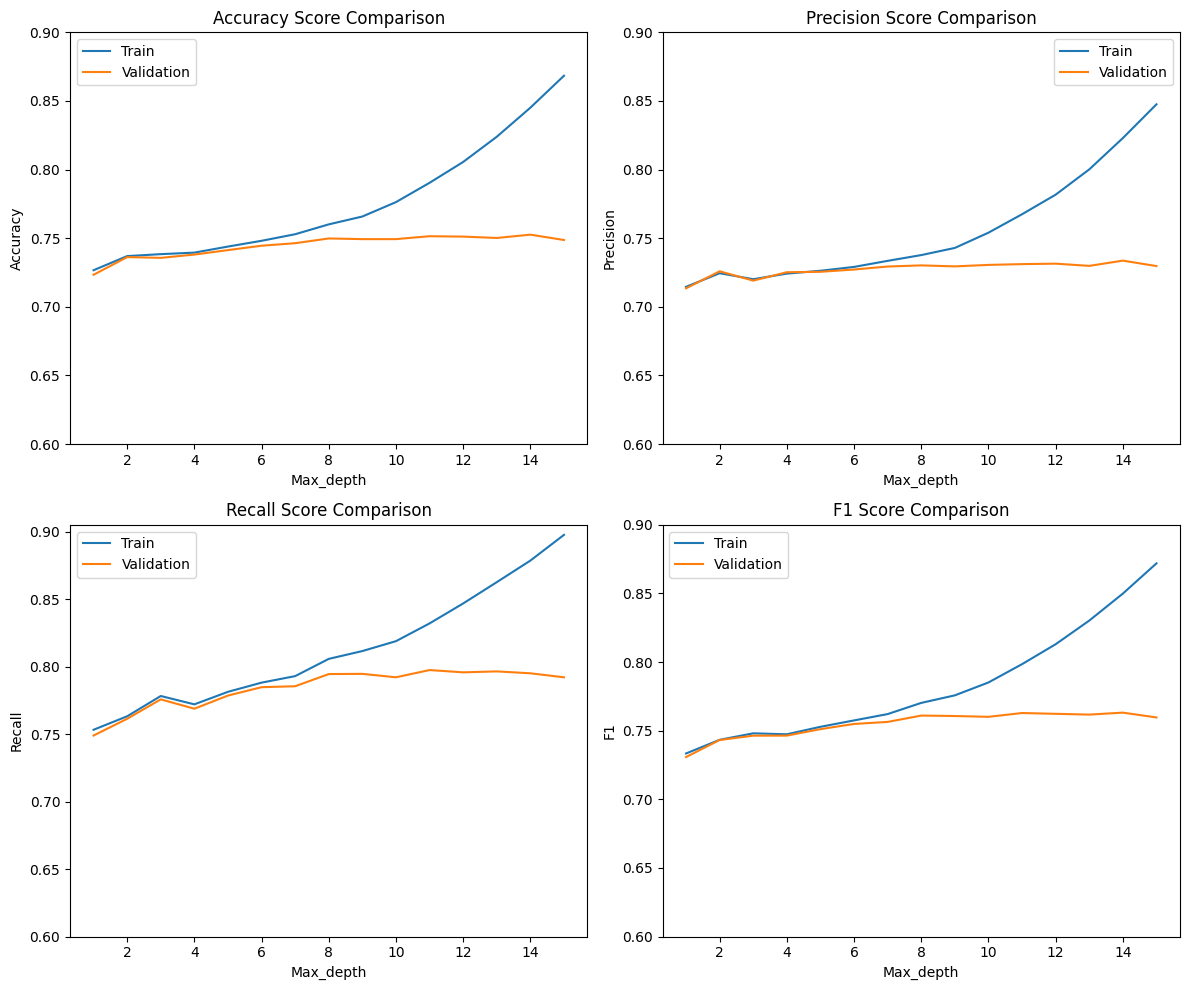

In [32]:
# plot line charts for max_depth
plot_model_metrics(pd.DataFrame(depth_models_rf), x_col="max_depth", save_path="./resources/random_forest_max_depth_metrics.png")

### Random Forest for best Estimators

In [33]:
# 8 max depth shows most stable and highest combination
# using max depth 8 for estimators
estimator_rf = [
    {**trainer(RandomForestClassifier(
        max_depth=8,
        n_estimators=estimator,
        criterion="gini",
        random_state=seed
        
    )), "estimator":estimator} for estimator in range(1,100)
]

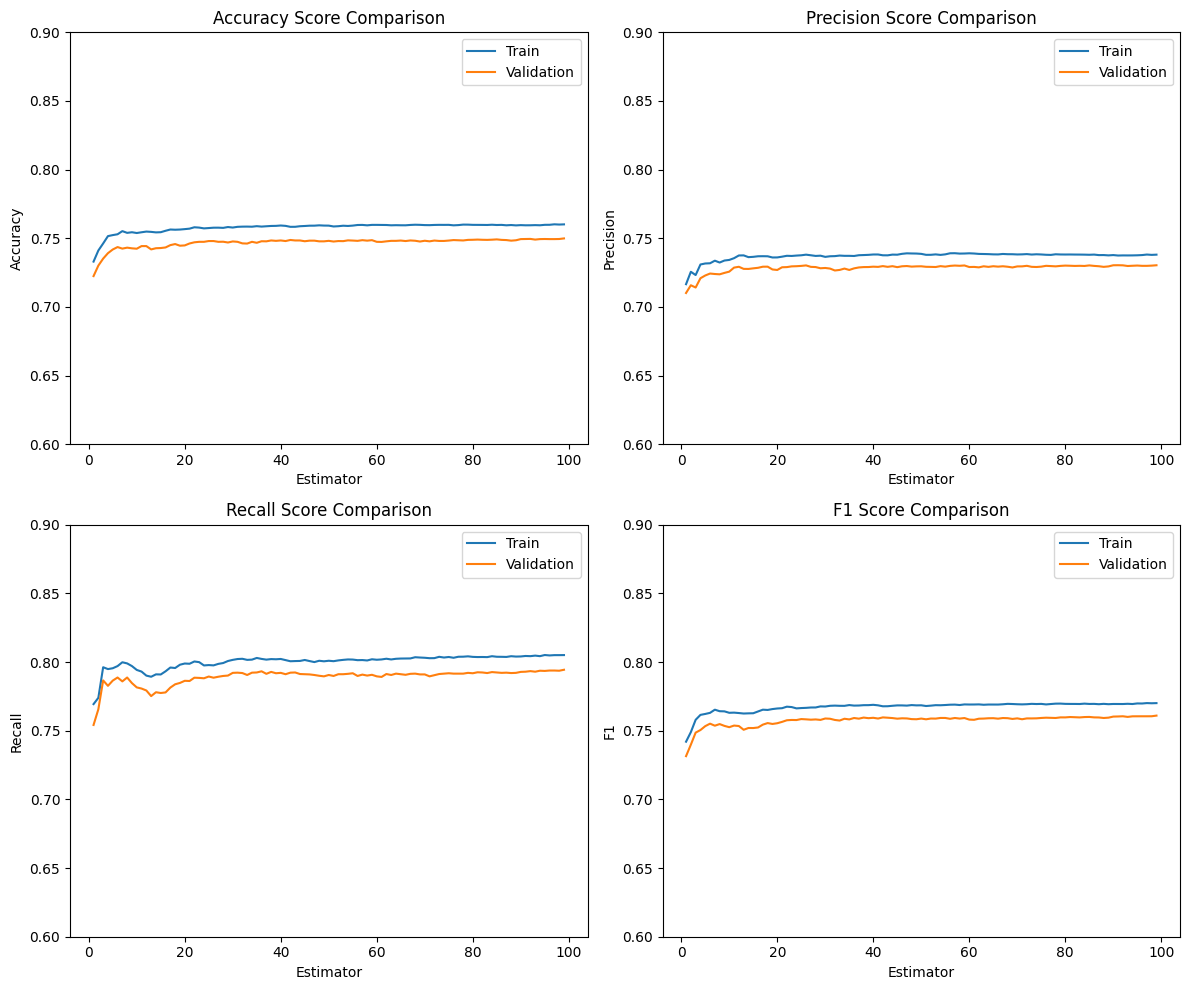

In [34]:
plot_model_metrics(pd.DataFrame(estimator_rf), x_col="estimator", save_path="./resources/random_forest_best_estimator.png")

### Use Tester in Random Forest

In [35]:
random_forest = next(item["model"] for item in estimator_rf if item["estimator"] == 40)

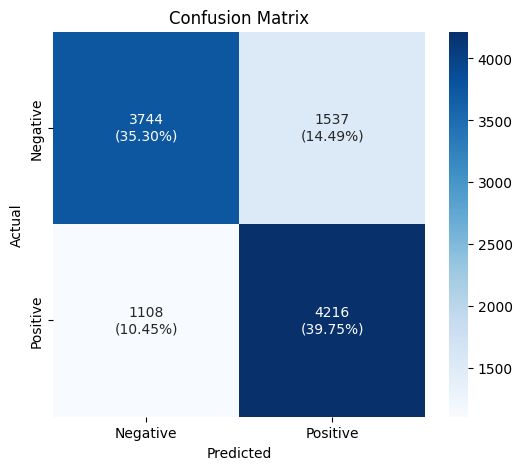

In [36]:
# tester models for random forest
rf_test = tester(random_forest, y_test, X_test)

# plot confusion matrix
plot_confusion_matrix(rf_test, save_path="./resources/confusuin_matrix_rf_test")

### Show ROC Curves for Random Forest's Best Model

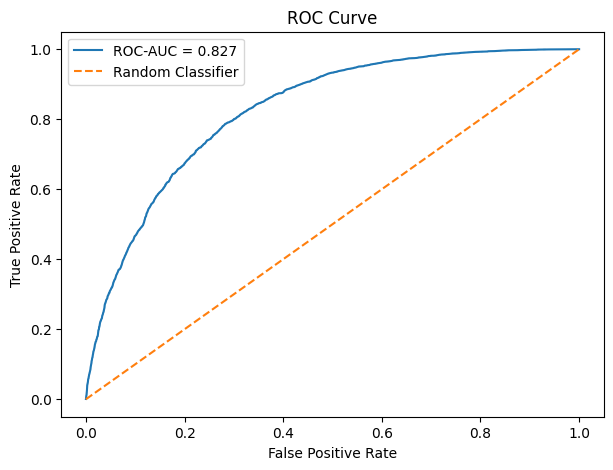

In [37]:
# plot roc auc curve
plot_roc_curve(rf_test, save_path="./resources/roc_rf_test.png")

## View where Error Occured
The random forest was selected as the final best model. So viewing where error occured in Random Forest.

In [38]:
# Generate predictions
y_pred = random_forest.predict(X_test)

# Create test results DataFrame
test_results = X_test.copy()

test_results["actual"] = y_test.to_numpy()
test_results["predicted"] = y_pred

# False negatives:
# Actual diabetes (1), but predicted non-diabetes (0)
false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
]

# False positives:
# Actual non-diabetes (0), but predicted diabetes (1)
false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
]

print(f"False Negatives: {len(false_negatives)}")
display(false_negatives.head())

print(f"False Positives: {len(false_positives)}")
display(false_positives.head())

False Negatives: 1108


,high_bp,high_cholesterol,cholesterol_check_5yrs,bmi,is_smoker,has_had_stroke,heart_disease_or_attack,physical_activity,eats_fruit_daily,eats_veggies_daily,heavy_alcohol,has_healthcare,no_doc_due_to_cost,general_health_rating,poor_mental_health_days,poor_physical_health_days,difficulty_walking,sex,age_category,education_level,income_level,actual,predicted
49020,0.0,0.0,1.0,-0.261504,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.044476,-0.463229,-0.578620,0.0,0.0,-1.600474,1.052125,1.056950,1.0,0.0
65268,0.0,0.0,1.0,1.007284,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.146040,-0.097831,-0.380290,0.0,0.0,-1.250409,1.052125,-0.778197,1.0,0.0
51368,1.0,1.0,1.0,-0.543457,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,-0.752395,-0.463229,0.016372,0.0,1.0,0.849978,1.052125,1.056950,1.0,0.0
40797,0.0,1.0,1.0,0.161425,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-1.650830,-0.463229,-0.578620,0.0,1.0,0.499914,1.052125,0.598163,1.0,0.0
36870,0.0,1.0,1.0,-0.543457,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,-0.752395,-0.463229,-0.380290,0.0,1.0,0.499914,0.081048,1.056950,1.0,0.0


False Positives: 1537


,high_bp,high_cholesterol,cholesterol_check_5yrs,bmi,is_smoker,has_had_stroke,heart_disease_or_attack,physical_activity,eats_fruit_daily,eats_veggies_daily,heavy_alcohol,has_healthcare,no_doc_due_to_cost,general_health_rating,poor_mental_health_days,poor_physical_health_days,difficulty_walking,sex,age_category,education_level,income_level,actual,predicted
8639,1.0,0.0,1.0,0.161425,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,-0.752395,-0.463229,-0.578620,0.0,0.0,0.499914,-0.890029,-0.319410,0.0,1.0
29740,1.0,1.0,1.0,0.020449,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.146040,-0.463229,-0.578620,1.0,1.0,0.499914,1.052125,1.056950,0.0,1.0
23007,1.0,1.0,1.0,0.020449,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,-0.752395,-0.463229,-0.578620,0.0,1.0,1.200043,-0.890029,0.139376,0.0,1.0
29154,1.0,1.0,1.0,-0.684433,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.044476,-0.463229,-0.578620,0.0,0.0,0.849978,-1.861105,-1.695770,0.0,1.0
11812,0.0,0.0,0.0,0.302402,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.942911,-0.463229,2.396341,1.0,1.0,0.499914,-0.890029,-0.778197,0.0,1.0
